In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/Amazon Sale Report.csv")

# Display the first 5 rows
df.head()

  df = pd.read_csv("/content/Amazon Sale Report.csv")


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [2]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42357 entries, 0 to 42356
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               42357 non-null  int64  
 1   Order ID            42357 non-null  object 
 2   Date                42356 non-null  object 
 3   Status              42356 non-null  object 
 4   Fulfilment          42356 non-null  object 
 5   Sales Channel       42356 non-null  object 
 6   ship-service-level  42356 non-null  object 
 7   Style               42356 non-null  object 
 8   SKU                 42356 non-null  object 
 9   Category            42356 non-null  object 
 10  Size                42356 non-null  object 
 11  ASIN                42356 non-null  object 
 12  Courier Status      39843 non-null  object 
 13  Qty                 42356 non-null  float64
 14  currency            39791 non-null  object 
 15  Amount              39791 non-null  float64
 16  ship

In [3]:
# Check for missing values
df.isnull().sum()

,0
index,0
Order ID,0
Date,1
Status,1
Fulfilment,1
Sales Channel,1
ship-service-level,1
Style,1
SKU,1
Category,1


In [4]:
# Display statistical summary of numerical columns
df.describe()

,index,Qty,Amount,ship-postal-code,Unnamed: 22
count,42357.000000,42356.000000,39791.000000,42343.000000,0.0
mean,21178.000000,0.900109,624.643361,463723.245802,NaN
std,12227.557013,0.331851,272.324462,194577.871649,NaN
min,0.000000,0.000000,0.000000,110001.000000,NaN
25%,10589.000000,1.000000,432.000000,380015.000000,NaN
50%,21178.000000,1.000000,568.570000,500019.000000,NaN
75%,31767.000000,1.000000,771.000000,600033.000000,NaN
max,42356.000000,15.000000,5584.000000,989898.000000,NaN


In [5]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [6]:
df = df.drop_duplicates()

In [7]:
print(df.columns)

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')


In [8]:
# Remove unnecessary columns
df.drop(columns=["Unnamed: 22"], inplace=True)

# Check remaining columns
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by'],
      dtype='object')

In [10]:
for col in df.columns:
    print(repr(col))

'index'
'Order ID'
'Date'
'Status'
'Fulfilment'
'Sales Channel '
'ship-service-level'
'Style'
'SKU'
'Category'
'Size'
'ASIN'
'Courier Status'
'Qty'
'currency'
'Amount'
'ship-city'
'ship-state'
'ship-postal-code'
'ship-country'
'promotion-ids'
'B2B'
'fulfilled-by'


In [11]:
df = df.dropna(subset=["Amount"])

In [12]:
df["Date"] = pd.to_datetime(df["Date"])

/tmp/ipykernel_659/936118274.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])
/tmp/ipykernel_659/936118274.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Date"] = pd.to_datetime(df["Date"])


In [13]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

/tmp/ipykernel_659/3360353459.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Year"] = df["Date"].dt.year
/tmp/ipykernel_659/3360353459.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Month"] = df["Date"].dt.month
/tmp/ipykernel_659/3360353459.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/ind

In [14]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Year,Month,Day
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,2022,4,30
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,2022,4,30
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,2022,4,30
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,2022,4,30
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,2022,4,30


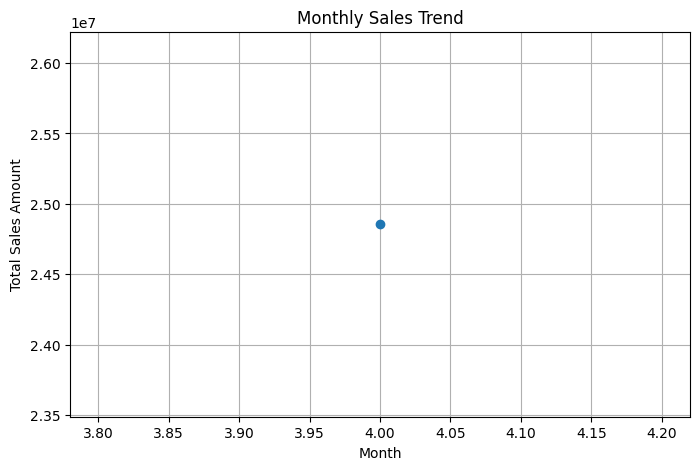

In [15]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby("Month")["Amount"].sum()

plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")
plt.grid(True)
plt.show()

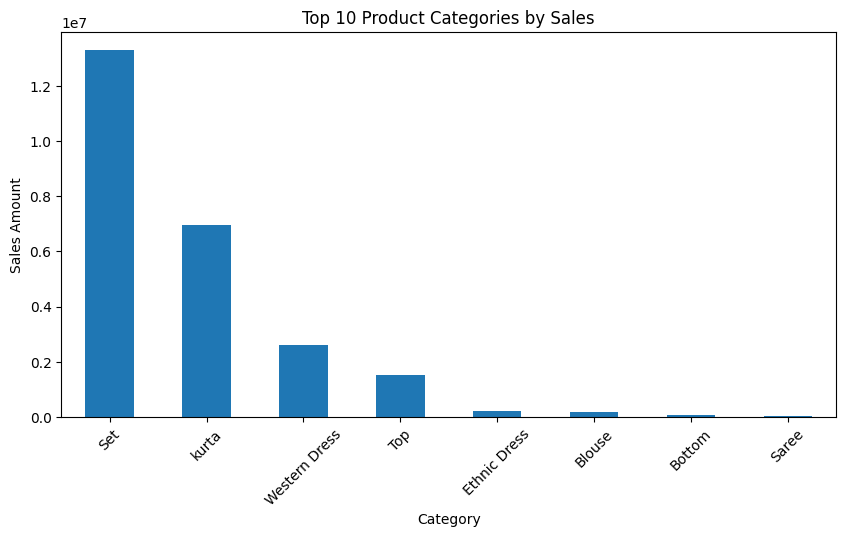

In [16]:
category_sales = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
category_sales.head(10).plot(kind="bar")
plt.title("Top 10 Product Categories by Sales")
plt.xlabel("Category")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.show()

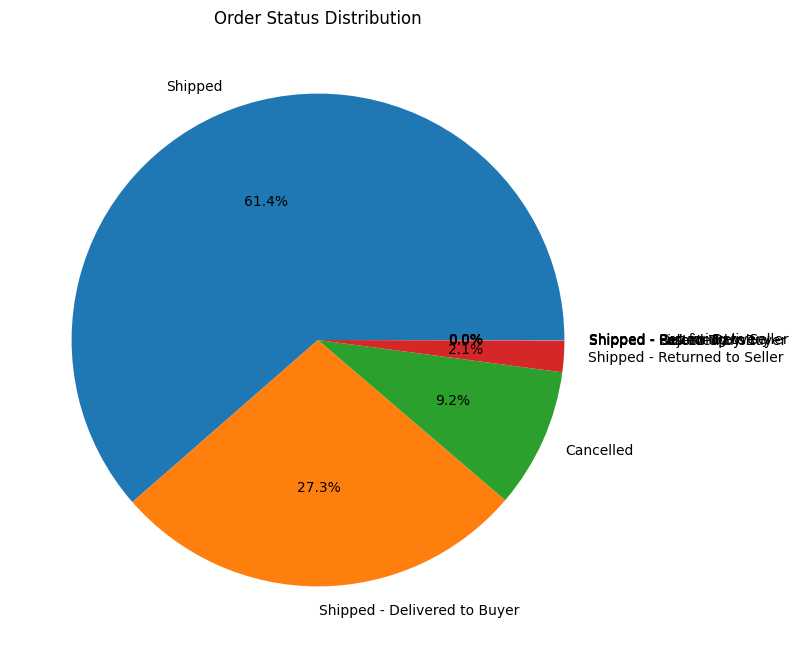

In [17]:
plt.figure(figsize=(8,8))
df["Status"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Order Status Distribution")
plt.ylabel("")
plt.show()

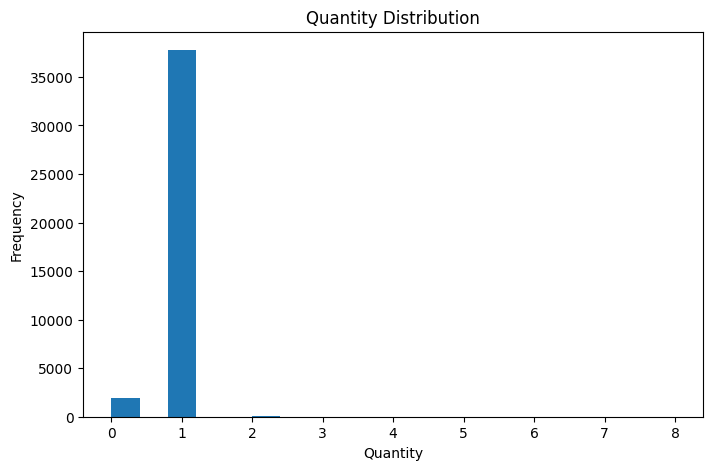

In [18]:
plt.figure(figsize=(8,5))
plt.hist(df["Qty"], bins=20)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

In [19]:
# Select features
features = [
    "Qty",
    "Month",
    "Day"
]

X = df[features]

# Target variable
y = df["Amount"]

print(X.head())
print(y.head())

   Qty  Month  Day
0  0.0      4   30
1  1.0      4   30
2  1.0      4   30
3  0.0      4   30
4  1.0      4   30
0    647.62
1    406.00
2    329.00
3    753.33
4    574.00
Name: Amount, dtype: float64


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (31832, 3)
Testing samples: (7959, 3)


In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [22]:
# Predict sales on the test data
y_pred = model.predict(X_test)

# Display first 5 predictions
print(y_pred[:5])

[626.37154878 630.8198739  520.97406092 632.18858932 626.02936992]


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 207.4052715031436
Mean Squared Error (MSE): 70778.40737886842
Root Mean Squared Error (RMSE): 266.04211579911254
R² Score: 0.0035592003373509096


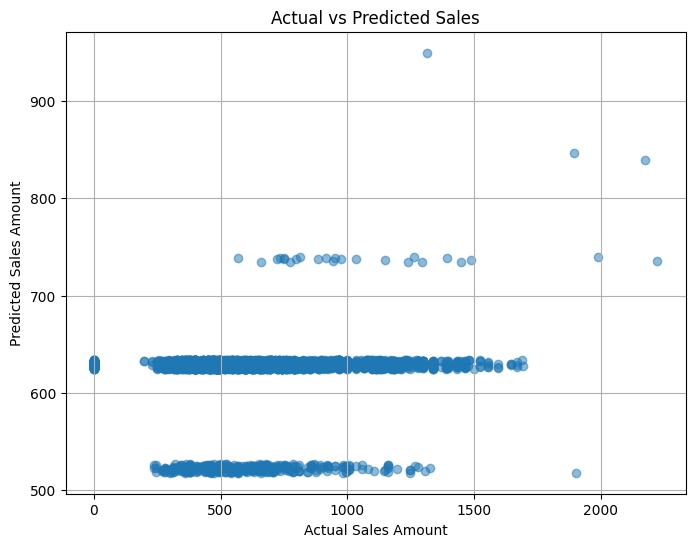

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Sales Amount")
plt.ylabel("Predicted Sales Amount")
plt.title("Actual vs Predicted Sales")
plt.grid(True)
plt.show()